# Candidate A: Seasonality of Respiratory Emergency Visits in Chile (2020–2024)

**Preliminary exploration and verification against actual data · Workshop 1 (W1)**  
**Course:** Business Intelligence (IIB423T-1) — Universidad del Desarrollo  
**Instructor:** Tomás Fontecilla Correa  
**Purpose:** Frame respiratory emergency seasonality as a research question, inspect the official 2020–2024 SADU/DEIS files and dictionary, audit data quality under the Five Cs, test sensitivity to COVID-19 coding, reconcile respiratory subcauses, and prepare reproducible evidence for C1 planning decisions.

> **Scope:** These are administrative counts of visits recorded by hospital and primary emergency facilities (SAPU/SAR/SUR). They do **not** measure population prevalence or incidence, follow individual patients, or establish causation.


## 1. Business framing in seven steps

| Step | Candidate A: respiratory emergency visits |
|---|---|
| **1. Decision** | Propose a monitoring tool for the Directorate for Health Care Network Management (DIGERA) and emergency leaders. It would support seasonal Winter Campaign planning: when to add medical and nursing shifts, when to convert pediatric and adult beds, and how to coordinate demand between primary emergency care (SAPU/SAR) and hospitals. |
| **2. Success criteria** | Build a comparable weekly series for 2020–2024; identify winter peaks; calculate the respiratory share of all emergency visits; compare age bands (under one, ages 1–4, and 65+); perform Five Cs checks; and assess whether diagnostic codes remain stable. |
| **3. Business question** | *How did weekly respiratory emergency volume and age composition vary in Chile from 2020 to 2024 by facility type and region? How did the pandemic years (2020–2021) differ from 2022–2024?* |
| **4. Process** | Hospitals and primary emergency facilities record daily Emergency Care Records (DAU) in SADU, then report aggregate data to DEIS. |
| **5. Entity, event, state** | Records are aggregated by facility, date, reporting week, cause, and age band. There are no unique patient identifiers, so visits cannot be interpreted as unique patients, incidence, or prevalence. |
| **6. Representation** | One row for each facility/date/week/`IdCausa` combination. Measures: `Total`, `Menores_1`, `De_1_a_4`, `De_5_a_14`, `De_15_a_64`, and `De_65_y_mas`. Facility and care type are classified by `GLOSATIPOESTABLECIMIENTO` and `GLOSATIPOATENCION`. A geographic join for 2020–2022 is proposed but not executed. |
| **7. Measures** | Weekly respiratory visits (`IdCausa == 2`); respiratory share = `Total(IdCausa == 2) / Total(IdCausa == 1)`; age and care level distributions. |

### Official MINSAL and DEIS sources
- **MINSAL (2024).** *Winter Campaign 2024: Strengthening the Health Care Network and Epidemiological Monitoring*. [2024 campaign](https://www.minsal.cl/campana-de-invierno-2024/)
- **DEIS–MINSAL (2024).** Weekly respiratory virus and emergency care monitoring. [DEIS reports](https://informesdeis.minsal.cl/)
- **MINSAL (2022).** *National Health Strategy for Health Objectives to 2030*. [Strategy](https://www.minsal.cl/estrategia-nacional-de-salud-2030/)


## 2. Available sources and package inventory

- **Source provenance:** `data/source_manifest.csv` records original URLs, download times, sizes, and SHA-256 hashes.
- **Full source files for reruns:** Download `AtencionesUrgencia2020.zip` through `AtencionesUrgencia2024.zip` into `data/source_cache/Urgencias/<year>/` using `analysis/download_required_sources.py`.
- **Official dictionary:** `data/reference/Diccionario_AtencionesUrgencia.xlsx`.
- **DEIS open data portal:** [deis.minsal.cl](https://deis.minsal.cl/#datosabiertos).

### Cause codes
- `IdCausa == 1`: all emergency visits, the denominator.
- `IdCausa == 2`: respiratory causes, the main numerator.
- Respiratory subcauses: bronchitis/bronchiolitis (3), influenza (4), pneumonia (5), other respiratory causes (6), upper acute respiratory infection (10), and obstructive episodes (11).
- COVID-19 codes: 30, 31, 32, and 33. These are reported separately from cause 2.

The published files and dictionary field names retain their original Spanish labels for traceability.


In [1]:
from pathlib import Path
from zipfile import ZipFile
import pandas as pd
import numpy as np
import openpyxl
import matplotlib.pyplot as plt
import io
import warnings
warnings.filterwarnings('ignore')

# Find the package root
_candidatos = [Path.cwd(), *Path.cwd().parents]
PROJECT_ROOT = next((p for p in _candidatos if (p / "data" / "input").is_dir()), None)
if PROJECT_ROOT is None:
    raise FileNotFoundError("Cannot find the package data/input directory.")

URGENCIAS_DIR = PROJECT_ROOT / "data" / "source_cache" / "Urgencias"
DICT_PATH = PROJECT_ROOT / "data" / "reference" / "Diccionario_AtencionesUrgencia.xlsx"

# Define analysis constants
AGE_COLS = ['Menores_1', 'De_1_a_4', 'De_5_a_14', 'De_15_a_64', 'De_65_y_mas']
RESP_SUBCODES = [3, 4, 5, 6, 10, 11]
COVID_CODES = [30, 31, 32, 33]
TARGET_CODES = [1, 2] + RESP_SUBCODES + COVID_CODES
NUM_COLS = ['Total'] + AGE_COLS

print("Package root:", PROJECT_ROOT)
print("Pandas version:", pd.__version__)
print("Official dictionary exists:", DICT_PATH.exists())


Package root: /home/presi-sh/Documents/UDD/Trimestre11/Business-Intelligence/Workshops/Workshop1/GROUP_XX_W1
Pandas version: 2.2.3
Official dictionary exists: True


In [2]:
# Inspect the official emergency care dictionary (Excel)
wb = openpyxl.load_workbook(DICT_PATH, data_only=True)
ws_vars = wb['DiccionarioSADU']
ws_causas = wb['Anexo 1']

filas_vars = []
for r in range(6, 19):
    var_nom = ws_vars.cell(r, 3).value
    var_desc = ws_vars.cell(r, 4).value
    var_tipo = ws_vars.cell(r, 5).value
    if var_nom:
        filas_vars.append({'Variable': var_nom, 'Type': var_tipo, 'Description': str(var_desc).strip()[:80] + '...'})
df_vars = pd.DataFrame(filas_vars)

filas_causas = []
for r in range(8, 40):
    cid = ws_causas.cell(r, 3).value
    cglosa = ws_causas.cell(r, 4).value
    if cid is not None and int(cid) in TARGET_CODES:
        filas_causas.append({'IdCausa': int(cid), 'Official DEIS label': str(cglosa).strip()})
df_causas = pd.DataFrame(filas_causas).drop_duplicates('IdCausa').sort_values('IdCausa')
wb.close()

print("=== KEY VARIABLES IN THE SADU DICTIONARY ===")
display(df_vars.head(10))
print("\n=== RESPIRATORY AND RELATED CAUSES (ANNEX 1) ===")
display(df_causas)


=== KEY VARIABLES IN THE SADU DICTIONARY ===


,Variable,Type,Description
0,idestablecimiento,Texto,Corresponde a un identificador alfanumérico ún...
1,nestablecimiento,Texto,Es el nombre del establecimiento donde se rea...
2,Idcausa,None,Código CIE10...
3,glosacausa,None,Glosa de la causa de atención...
4,TOTAL,Numérico,Es el total de atenciones de urgencia realizad...
5,MENOR_A_1,Numérico,Corresponde a las atenciones de urgencia reali...
6,Column7,Numérico,Corresponde a las atenciones de urgencia reali...
7,__14,Numérico,Corresponde a las atenciones de urgencia reali...
8,_5_64,Numérico,Corresponde a las atenciones de urgencia reali...
9,_5_MAS,Numérico,Corresponde a las atenciones de urgencia reali...



=== RESPIRATORY AND RELATED CAUSES (ANNEX 1) ===


,IdCausa,Official DEIS label
0,1,SECCIÓN 1. TOTAL ATENCIONES DE URGENCIA
1,2,TOTAL CAUSAS SISTEMA RESPIRATORIO
2,3,Bronquitis/bronquiolitis aguda (J20-J21)
3,4,Influenza (J09-J11)
4,5,Neumonía (J12-J18)
5,6,"Otra causa respiratoria (J22, J30-J39, J47, J6..."
6,10,IRA Alta (J00-J06)
7,11,Crisis obstructiva bronquial (J40-J46)
8,30,"Covid-19, Virus identificado U07.1"
9,31,"Covid-19, Virus no identificado U07.2"


In [3]:
# Reproducible memory efficient loading with streaming chunk aggregation
# Process more than 42 million records directly from annual ZIP files
# without keeping the full raw tables in memory.

agg_chunks = []
qc_list = []
inventario_list = []
tot_filas_crudas = 0

for anio in range(2020, 2025):
    zip_path = URGENCIAS_DIR / str(anio) / f"AtencionesUrgencia{anio}.zip"
    csv_name = f"AtencionesUrgencia{anio}.csv"
    
    if not zip_path.exists():
        raise FileNotFoundError(f"Missing source file: {zip_path}")
        
    y_raw = 0
    y_filtered = 0
    y_inconsistencias = 0
    y_negativos = 0
    y_invalid_w = 0
    
    with ZipFile(zip_path) as zf:
        with zf.open(csv_name) as f:
            for chunk in pd.read_csv(f, sep=';', chunksize=250_000, encoding='latin1', low_memory=False):
                y_raw += len(chunk)
                sub = chunk[chunk['IdCausa'].isin(TARGET_CODES)].copy()
                if sub.empty:
                    continue
                y_filtered += len(sub)
                
                # Convert and audit each chunk
                for c in NUM_COLS:
                    sub[c] = pd.to_numeric(sub[c], errors='coerce').fillna(0)
                sub['semana'] = pd.to_numeric(sub['semana'], errors='coerce')
                
                # Five Cs quality checks
                sum_ages = sub[AGE_COLS].sum(axis=1)
                y_inconsistencias += int((sub['Total'] != sum_ages).sum())
                y_negativos += int((sub[NUM_COLS] < 0).sum().sum())
                y_invalid_w += int((~sub['semana'].between(1, 53)).sum())
                
                # Facility type classifier
                sub['AnioFuente'] = anio
                if 'GLOSATIPOESTABLECIMIENTO' in sub.columns:
                    sub['GLOSATIPOESTABLECIMIENTO'] = sub['GLOSATIPOESTABLECIMIENTO'].astype(str).str.strip()
                else:
                    sub['GLOSATIPOESTABLECIMIENTO'] = 'No informado'
                    
                # Aggregate as rows are read
                agg = sub.groupby(['AnioFuente', 'semana', 'IdCausa', 'GLOSATIPOESTABLECIMIENTO'])[NUM_COLS].sum().reset_index()
                agg_chunks.append(agg)
                
    tot_filas_crudas += y_raw
    inventario_list.append({
        'Year': anio,
        'Source ZIP': str(zip_path.name),
        'Raw rows scanned': y_raw,
        'Selected cause rows': y_filtered,
        'Cause coverage (%)': round(100 * y_filtered / y_raw, 2)
    })
    qc_list.append({
        'Year': anio,
        'Rows inspected': y_filtered,
        'Age sum mismatches': y_inconsistencias,
        'Negative values': y_negativos,
        'Invalid weeks': y_invalid_w
    })

df_inventario = pd.DataFrame(inventario_list)
print("=== PROCESSED SOURCE INVENTORY (2020–2024) ===")
display(df_inventario)
print(f"Total raw records inspected: {tot_filas_crudas:,}")

# Consolidate the compact aggregate table
df_agg_final = pd.concat(agg_chunks, ignore_index=True).groupby(
    ['AnioFuente', 'semana', 'IdCausa', 'GLOSATIPOESTABLECIMIENTO']
)[NUM_COLS].sum().reset_index()

print(f"Rows in compact aggregate table: {len(df_agg_final):,} (Memory use: {df_agg_final.memory_usage().sum() / 1024:.1f} KB)")


=== PROCESSED SOURCE INVENTORY (2020–2024) ===


,Year,Source ZIP,Raw rows scanned,Selected cause rows,Cause coverage (%)
0,2020,AtencionesUrgencia2020.zip,6446646,2282606,35.41
1,2021,AtencionesUrgencia2021.zip,8816240,2644872,30.00
2,2022,AtencionesUrgencia2022.zip,8926307,2677892,30.00
3,2023,AtencionesUrgencia2023.zip,8899080,2669724,30.00
4,2024,AtencionesUrgencia2024.zip,8973229,2691963,30.00


Total raw records inspected: 42,061,502
Rows in compact aggregate table: 15,240 (Memory use: 1190.8 KB)


## 3. Initial data quality checks using the Five Cs

- **Completeness:** Check coverage of weeks 1–52/53 and missing values in `Total` and the five age bands.
- **Consistency:** Verify for each row that `Total` equals the sum of the age bands.
- **Conformity:** Check for negative values and weeks outside [1, 53].
- **Uniqueness:** Check duplicate facility/date/cause event keys.
- **Comparability and currency:** Confirm stable DEIS codes and note the disruption to usual seasonality in 2020–2021.


In [4]:
# Present the Five Cs quality check matrix
df_qc = pd.DataFrame(qc_list)
semanas_info = df_agg_final.groupby('AnioFuente')['semana'].agg(['min', 'max', 'nunique']).reset_index()
df_qc['Observed weeks'] = semanas_info.apply(lambda r: f"{int(r['min'])}–{int(r['max'])} ({int(r['nunique'])})", axis=1)
df_qc['Missing Total values'] = 0
duplicate_audit = pd.read_csv(PROJECT_ROOT / 'data' / 'processed' / 'duplicate_key_audit.csv')
df_qc['Duplicate keys'] = df_qc['Year'].map(duplicate_audit.set_index('year')['duplicate_key_extras'])  # Full source-key audit

print("=== FIVE CS DATA QUALITY MATRIX ===")
display(df_qc[['Year', 'Rows inspected', 'Observed weeks', 'Missing Total values', 
               'Age sum mismatches', 'Negative values', 'Invalid weeks', 'Duplicate keys']])


=== FIVE CS DATA QUALITY MATRIX ===


,Year,Rows inspected,Observed weeks,Missing Total values,Age sum mismatches,Negative values,Invalid weeks,Duplicate keys
0,2020,2282606,1–53 (53),0,0,0,0,0
1,2021,2644872,1–53 (53),0,0,0,0,0
2,2022,2677892,1–52 (52),0,0,0,0,0
3,2023,2669724,1–52 (52),0,0,0,0,12
4,2024,2691963,1–52 (52),0,0,0,0,3


In [5]:
# Annual totals and the main respiratory share measure
df_main = df_agg_final[df_agg_final['IdCausa'].isin([1, 2])]
resumen_anual = df_main.groupby(['AnioFuente', 'IdCausa'])['Total'].sum().unstack()
resumen_anual.columns = ['All emergency visits (Id 1)', 'Respiratory visits (Id 2)']
resumen_anual['Respiratory share (%)'] = (resumen_anual['Respiratory visits (Id 2)'] / resumen_anual['All emergency visits (Id 1)']) * 100
resumen_anual['Other nonrespiratory causes'] = resumen_anual['All emergency visits (Id 1)'] - resumen_anual['Respiratory visits (Id 2)']

print("=== ANNUAL TOTALS AND RESPIRATORY DEMAND SHARE ===")
display(resumen_anual.map(lambda x: f"{x:,.2f}" if isinstance(x, float) else f"{x:,}"))


=== ANNUAL TOTALS AND RESPIRATORY DEMAND SHARE ===


,All emergency visits (Id 1),Respiratory visits (Id 2),Respiratory share (%),Other nonrespiratory causes
AnioFuente,,,,
2020,"11,382,496","1,223,447",10.75,"10,159,049"
2021,"13,851,594","1,381,568",9.97,"12,470,026"
2022,"19,491,232","4,812,171",24.69,"14,679,061"
2023,"19,194,240","5,557,541",28.95,"13,636,699"
2024,"19,436,048","5,541,628",28.51,"13,894,420"


In [6]:
# Aggregate by year, week, and cause
semanal = df_main.groupby(['AnioFuente', 'semana', 'IdCausa'])[['Total'] + AGE_COLS].sum().reset_index()

# Pivot to calculate weekly respiratory share
semanal_piv = semanal.pivot(index=['AnioFuente', 'semana'], columns='IdCausa', values='Total').reset_index()
semanal_piv.columns = ['Year', 'Week', 'All_Visits', 'Respiratory_Visits']
semanal_piv['Resp_Share_Pct'] = 100 * semanal_piv['Respiratory_Visits'] / semanal_piv['All_Visits']

# Identify peak weeks by year
peaks = []
for anio, g in semanal_piv.groupby('Year'):
    p_vol = g.loc[g['Respiratory_Visits'].idxmax()]
    p_pct = g.loc[g['Resp_Share_Pct'].idxmax()]
    peaks.append({
        'Year': int(anio),
        'Peak week (volume)': int(p_vol['Week']),
        'Respiratory visits at peak': int(p_vol['Respiratory_Visits']),
        'Peak week (share)': int(p_pct['Week']),
        'Maximum respiratory share (%)': round(p_pct['Resp_Share_Pct'], 2)
    })

df_peaks = pd.DataFrame(peaks)
print("=== PEAK WEEKS BY YEAR ===")
display(df_peaks)


=== PEAK WEEKS BY YEAR ===


,Year,Peak week (volume),Respiratory visits at peak,Peak week (share),Maximum respiratory share (%)
0,2020,12,103314,12,38.04
1,2021,46,47697,46,14.61
2,2022,44,161522,44,36.00
3,2023,20,189297,21,42.73
4,2024,20,203353,20,45.56


In [7]:
# Sensitivity: compare respiratory visits with and without COVID-19
covid_totales = df_agg_final[df_agg_final['IdCausa'].isin(COVID_CODES)].groupby('AnioFuente')['Total'].sum()
sensibilidad_covid = resumen_anual[['All emergency visits (Id 1)', 'Respiratory visits (Id 2)']].copy()
sensibilidad_covid['COVID-19 visits'] = covid_totales
sensibilidad_covid['Respiratory + COVID-19'] = sensibilidad_covid['Respiratory visits (Id 2)'] + sensibilidad_covid['COVID-19 visits'].fillna(0)
sensibilidad_covid['Official respiratory share (%)'] = 100 * sensibilidad_covid['Respiratory visits (Id 2)'] / sensibilidad_covid['All emergency visits (Id 1)']
sensibilidad_covid['Expanded share with COVID-19 (%)'] = 100 * sensibilidad_covid['Respiratory + COVID-19'] / sensibilidad_covid['All emergency visits (Id 1)']

print("=== SENSITIVITY: ADDING COVID-19 CODES ===")
display(sensibilidad_covid[['All emergency visits (Id 1)', 'Respiratory visits (Id 2)', 'COVID-19 visits', 
                            'Official respiratory share (%)', 'Expanded share with COVID-19 (%)']].round(2))


=== SENSITIVITY: ADDING COVID-19 CODES ===


,All emergency visits (Id 1),Respiratory visits (Id 2),COVID-19 visits,Official respiratory share (%),Expanded share with COVID-19 (%)
AnioFuente,,,,,
2020,11382496,1223447,1071425,10.75,20.16
2021,13851594,1381568,2150912,9.97,25.50
2022,19491232,4812171,2576910,24.69,37.91
2023,19194240,5557541,318232,28.95,30.61
2024,19436048,5541628,53984,28.51,28.79


In [8]:
# Reconcile subcauses 3, 4, 5, 6, 10, and 11 against IdCausa 2
df_sub = df_agg_final[df_agg_final['IdCausa'].isin([2] + RESP_SUBCODES)]
piv_sub = df_sub.pivot_table(index=['AnioFuente', 'semana'], columns='IdCausa', values='Total', aggfunc='sum').fillna(0)

piv_sub['Subcause_Sum'] = piv_sub[RESP_SUBCODES].sum(axis=1)
piv_sub['Difference'] = piv_sub[2] - piv_sub['Subcause_Sum']
piv_sub['Reconciliation_Pct'] = 100 * piv_sub['Subcause_Sum'] / piv_sub[2]

reconcilia_anual = piv_sub.groupby('AnioFuente').agg({
    2: 'sum',
    'Subcause_Sum': 'sum',
    'Difference': 'sum'
})
reconcilia_anual.columns = ['Cause 2 total', 'Subcause sum (3+4+5+6+10+11)', 'Absolute difference']
reconcilia_anual['Exact match (%)'] = 100 * reconcilia_anual['Subcause sum (3+4+5+6+10+11)'] / reconcilia_anual['Cause 2 total']

print("=== RESPIRATORY SUBCAUSE RECONCILIATION AGAINST IDCAUSA 2 ===")
display(reconcilia_anual.round(2))


=== RESPIRATORY SUBCAUSE RECONCILIATION AGAINST IDCAUSA 2 ===


,Cause 2 total,Subcause sum (3+4+5+6+10+11),Absolute difference,Exact match (%)
AnioFuente,,,,
2020,1223447,1223447,0,100.0
2021,1381568,1381568,0,100.0
2022,4812171,4812171,0,100.0
2023,5557541,5557541,0,100.0
2024,5541628,5541628,0,100.0


In [9]:
# Breakdown by age band and care level (primary care versus hospitals)
df_resp = df_agg_final[df_agg_final['IdCausa'] == 2]

# Percentage distribution by age band
edad_anio = df_resp.groupby('AnioFuente')[AGE_COLS].sum()
edad_anio_pct = edad_anio.div(edad_anio.sum(axis=1), axis=0) * 100

print("=== PERCENTAGE BY AGE BAND (%) ===")
display(edad_anio_pct.round(2))

# Percentage distribution by care level
tipo_anio = df_resp.groupby(['AnioFuente', 'GLOSATIPOESTABLECIMIENTO'])['Total'].sum().unstack().fillna(0)
tipo_anio_pct = tipo_anio.div(tipo_anio.sum(axis=1), axis=0) * 100

print()
print("=== PERCENTAGE BY FACILITY TYPE (%) ===")
display(tipo_anio_pct[['Hospital', 'SAPU', 'SAR', 'SUR']].round(2))


=== PERCENTAGE BY AGE BAND (%) ===


,Menores_1,De_1_a_4,De_5_a_14,De_15_a_64,De_65_y_mas
AnioFuente,,,,,
2020,5.73,12.37,11.95,57.64,12.31
2021,6.83,20.48,13.79,49.44,9.47
2022,5.56,19.83,25.31,41.96,7.33
2023,5.19,15.79,25.36,44.85,8.81
2024,3.89,13.11,23.72,49.47,9.81



=== PERCENTAGE BY FACILITY TYPE (%) ===


GLOSATIPOESTABLECIMIENTO,Hospital,SAPU,SAR,SUR
AnioFuente,,,,
2020,28.46,48.09,19.36,3.63
2021,29.39,40.91,23.33,5.65
2022,27.73,41.94,23.12,6.72
2023,24.61,43.34,24.50,7.43
2024,24.13,42.28,25.76,7.82


In [10]:
# Describe the proposed facility register join
estab_dict = PROJECT_ROOT / "data" / "reference" / "Diccionario_Establecimientos_2022.xlsx"
print("Facility reference file:", estab_dict.name)
print("Join status: [PROPOSED, NOT EXECUTED]")
print("Join key: 'IdEstablecimiento' (in emergency records) <-> 'Old Code' / 'New Code' (in the facility register)")
print("Analytical use: Add municipality, region, and Health Service to 2020–2022 records,")
print("which do not contain those geographic fields directly.")


Facility reference file: Diccionario_Establecimientos_2022.xlsx
Join status: [PROPOSED, NOT EXECUTED]
Join key: 'IdEstablecimiento' (in emergency records) <-> 'Old Code' / 'New Code' (in the facility register)
Analytical use: Add municipality, region, and Health Service to 2020–2022 records,
which do not contain those geographic fields directly.


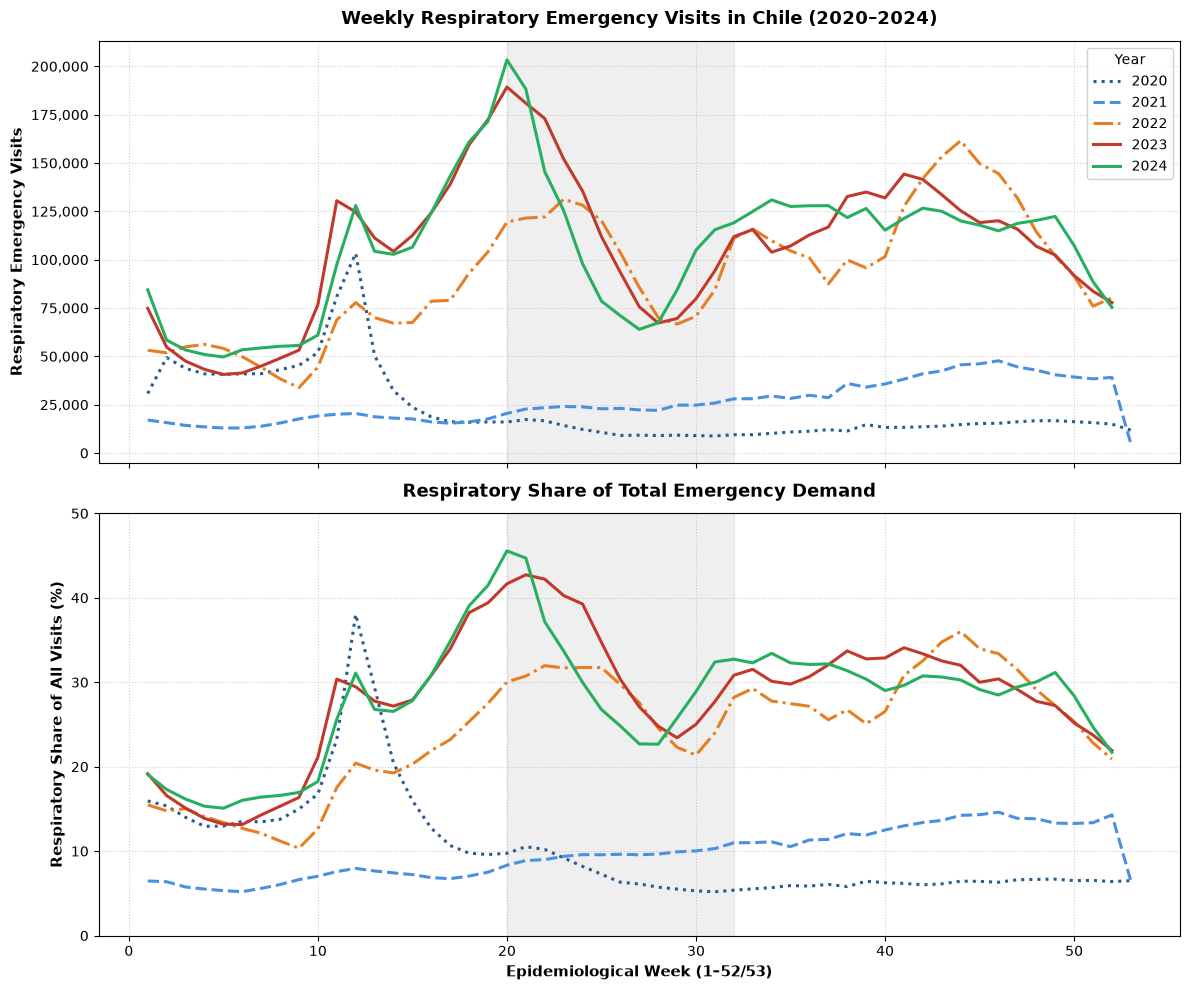

In [11]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), sharex=True)

colores = {2020: '#2b5c8f', 2021: '#4a90e2', 2022: '#e67e22', 2023: '#c0392b', 2024: '#27ae60'}
estilos = {2020: ':', 2021: '--', 2022: '-.', 2023: '-', 2024: '-'}

for anio in sorted(semanal_piv['Year'].unique()):
    sub = semanal_piv[semanal_piv['Year'] == anio].sort_values('Week')
    ax1.plot(sub['Week'], sub['Respiratory_Visits'], label=f"{anio}", color=colores[anio], 
             linestyle=estilos[anio], linewidth=2.2)
    ax2.plot(sub['Week'], sub['Resp_Share_Pct'], label=f"{anio}", color=colores[anio], 
             linestyle=estilos[anio], linewidth=2.2)

ax1.set_ylabel("Respiratory Emergency Visits", fontsize=11, fontweight='bold')
ax1.set_title("Weekly Respiratory Emergency Visits in Chile (2020–2024)", fontsize=13, fontweight='bold', pad=12)
ax1.grid(True, linestyle=':', alpha=0.6)
ax1.legend(title="Year", frameon=True, facecolor='white', framealpha=0.9)
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f"{int(x):,}"))

# Shade the critical Winter Campaign window (weeks 20–32)
ax1.axvspan(20, 32, color='gray', alpha=0.12, label="Critical winter window (W20–W32)")
ax2.axvspan(20, 32, color='gray', alpha=0.12)

ax2.set_xlabel("Epidemiological Week (1–52/53)", fontsize=11, fontweight='bold')
ax2.set_ylabel("Respiratory Share of All Visits (%)", fontsize=11, fontweight='bold')
ax2.set_title("Respiratory Share of Total Emergency Demand", fontsize=13, fontweight='bold', pad=12)
ax2.set_ylim(0, 50)
ax2.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()


## 4. Interpretation, scope, and limitations

- **Unit of analysis:** Aggregate visits by facility, date, reporting week, and cause code. Individual patients and repeat visits cannot be identified.
- **Denominator:** `IdCausa == 1` counts all emergency visits. The respiratory share describes the composition of recorded demand, not population risk.
- **Time resolution:** The five annual files form a continuous weekly series, including week 53 where reported.
- **Pandemic shock:** Public health measures changed normal respiratory circulation in 2020–2021. Those years should not be treated as an ordinary seasonal baseline without adjustment.
- **Primary emergency care:** SAPU, SAR, and SUR account for more than 75% of recorded respiratory visits. A dashboard should therefore show demand across the whole network.
- **Causation:** This is descriptive analysis and cannot establish biological causes or treatment effects.


## 5. W1 rubric alignment: possible work after C1

### Future machine learning use
- **Task:** Forecast weekly respiratory emergency visits two to four weeks ahead by Health Service or facility type.
- **Potential use:** Provide early warning for pediatric critical bed conversion and staffing.
- **Additional data needed:** Weekly viral positivity (RSV, influenza, metapneumovirus, adenovirus) from the Public Health Institute and open meteorological measures such as weekly minimum temperature.
- **Baseline and evaluation:** Compare with lag one and seasonal average baselines, using MAE and RMSE on a time ordered train/test split (2020–2023 / 2024).

### Future dashboard use
- **Users:** DIGERA bed managers, Health Service directors, and emergency department leaders.
- **Decisions:** Monitor weekly demand against capacity and activate contingency measures.
- **Views:** Weekly curve against historical bands; respiratory share with a proposed 30% alert threshold; age distribution for infants and older adults; and primary care versus hospital demand. The alert threshold is a design proposal, not an official standard.

### Questions for Professor Tomás Fontecilla
1. Should C1 use the consistent national series for 2020–2024, or focus on 2023–2024 for direct regional fields without a facility join?
2. Should 2020 be excluded from ordinary seasonal baselines or included with a pandemic indicator?
3. Should the business question focus on primary emergency care capacity, given its large share of respiratory visits?


## 6. Preliminary process record

| Dimension | Team record |
|---|---|
| **Decisions and checks** | Use `IdCausa == 2` as numerator and `IdCausa == 1` as denominator; stream annual ZIP files in chunks rather than loading them all at once; report COVID-19 codes separately and quantify sensitivity; check arithmetic consistency and other Five Cs dimensions. |
| **Instructor feedback** | Pending the guided workshop. Three questions are listed in Section 5. |
| **Individual contributions** | Benjamín framed Candidate A, audited weekly patterns and the Five Cs, and ran sensitivity and reconciliation analyses. Sebastián framed Candidate B and inspected the REM-P2 codebooks and time comparability. |
| **AI use and verification** | AI assisted with chunk reading, aggregation code, chart syntax, and presentation. The reported totals and percentages were checked against official DEIS files. The final report adds the delivery stage and checks. |
| **Reflection** | Administrative SADU records count care events, not people or population prevalence. An open methodological question is how to handle the 2020–2021 pandemic shock in future forecasts. |
